<a href="https://colab.research.google.com/github/rdelhibabu/RT_QP/blob/main/RT_QP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# [Colab Markdown: ## 1. Dependencies and Setup]
!pip install qutip numpy matplotlib torch gymnasium

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import qutip as qt
import gymnasium as gym
from gymnasium import spaces
import matplotlib.pyplot as plt
from collections import deque
import random

# Device configuration (Use GPU if available in Colab)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 28.5/28.5 MB 59.5 MB/s eta 0:00:00
Training on: cpu


In [15]:
# [Colab Markdown: ## 2. NV Center Simulation Environment (Rotating Frame)]
class NVSimulatorEnv(gym.Env):
    """
    Simulates the NV Center ground state dynamics at 298K.
    Operates in the Rotating Frame to eliminate 2.87 GHz ODE solver stiffness.
    Action Space: Continuous [delay (tau), phase (phi), amplitude (Omega)]
    State Space: [t_total, tau_prev, phi_prev, Omega_prev, target_state_vector]
    """
    def __init__(self, max_steps=64):
        super(NVSimulatorEnv, self).__init__()
        self.max_steps = max_steps
        self.current_step = 0

        # Physical Constants & Hardware Limits (Table 3)
        # Note: self.D = 2.87e9 is mathematically removed via the Rotating Frame
        self.gamma_e = 28.024e9  # Gyromagnetic ratio
        self.tau_bounds = (0.5e-9, 5.0e-6)
        self.phi_bounds = (0.0, 2 * np.pi)
        self.omega_bounds = (0.0, 40e6)

        # Action space: Normalized [-1, 1] for DDPG stability
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(3,), dtype=np.float32)

        # Observation space
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(5,), dtype=np.float32)

        # Quantum States (qutip)
        self.basis_0 = qt.basis(2, 0)
        self.basis_1 = qt.basis(2, 1)
        self.rho_ideal = qt.ket2dm((self.basis_0 + self.basis_1).unit()) # Target: Superposition

    def reset(self, seed=None):
        self.current_step = 0
        self.state_history = []
        self.rho_current = qt.ket2dm(self.basis_0) # Initial state |0>

        # Initial observation: [t_total=0, prev actions=0, target info]
        self.state = np.array([0.0, 0.0, 0.0, 0.0, 1.0], dtype=np.float32)
        return self.state, {}

    def _denormalize_action(self, action):
        tau = np.interp(action[0], [-1, 1], self.tau_bounds)
        phi = np.interp(action[1], [-1, 1], self.phi_bounds)
        omega = np.interp(action[2], [-1, 1], self.omega_bounds)
        return tau, phi, omega

    def step(self, action):
        tau, phi, omega = self._denormalize_action(action)

        # 1. Free Evolution (Delay tau) with Thermal Noise (Rotating Frame)
        # We drop the 2.87 GHz 'D' term to prevent ODE solver overload.
        noise_detuning = self._generate_thermal_noise(tau)
        H_free = noise_detuning * qt.sigmaz()

        # Default mesolve options work perfectly now
        self.rho_current = qt.mesolve(H_free, self.rho_current, [0, tau]).states[-1]

        # 2. Microwave Pulse Application (Amplitude omega, Phase phi)
        t_p = 10e-9 # Fixed pi-pulse duration
        H_pulse = omega * (np.cos(phi) * qt.sigmax() + np.sin(phi) * qt.sigmay())
        self.rho_current = qt.mesolve(H_pulse, self.rho_current, [0, t_p]).states[-1]

        self.current_step += 1
        self.state[0] += (tau + t_p) # Update t_total
        self.state[1:4] = [tau, phi, omega] # Update history

        done = self.current_step >= self.max_steps

        # Reward Calculation (Equation 7)
        reward = 0
        if done:
            fidelity = qt.fidelity(self.rho_current, self.rho_ideal) ** 2
            energy_penalty = 1e-15 * (omega ** 2) * t_p # Lambda scaling
            reward = fidelity - energy_penalty

        return self.state, reward, done, False, {"fidelity": qt.fidelity(self.rho_current, self.rho_ideal)**2 if done else 0}

    def _generate_thermal_noise(self, duration):
        # Placeholder: Gaussian noise modeling non-Markovian bumps
        return np.random.normal(0, 1e5)

In [16]:
# [Colab Markdown: ## 3. DDPG Actor-Critic Networks]
class Actor(nn.Module):
    def __init__(self, state_dim, action_dim, max_action):
        super(Actor, self).__init__()
        self.layer1 = nn.Linear(state_dim, 256)
        self.layer2 = nn.Linear(256, 256)
        self.layer3 = nn.Linear(256, action_dim)
        self.max_action = max_action

    def forward(self, x):
        x = torch.relu(self.layer1(x))
        x = torch.relu(self.layer2(x))
        # Tanh bounds output between -1 and 1
        return self.max_action * torch.tanh(self.layer3(x))

class Critic(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(Critic, self).__init__()
        # Q1 architecture
        self.layer1 = nn.Linear(state_dim + action_dim, 256)
        self.layer2 = nn.Linear(256, 256)
        self.layer3 = nn.Linear(256, 1)

    def forward(self, state, action):
        sa = torch.cat([state, action], 1)
        q = torch.relu(self.layer1(sa))
        q = torch.relu(self.layer2(q))
        return self.layer3(q)

class ReplayBuffer:
    def __init__(self, max_size=1e6):
        self.buffer = deque(maxlen=int(max_size))

    def add(self, transition):
        self.buffer.append(transition)

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = map(np.stack, zip(*batch))
        return (
            torch.FloatTensor(state).to(device),
            torch.FloatTensor(action).to(device),
            torch.FloatTensor(reward).unsqueeze(1).to(device),
            torch.FloatTensor(next_state).to(device),
            torch.FloatTensor(np.float32(done)).unsqueeze(1).to(device)
        )

In [17]:
# [Colab Markdown: ## 4. Pre-Training Loop (Algorithm 1)]
def train_ddpg(env, episodes=5000, batch_size=64, gamma=0.99, tau_update=0.005):
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.shape[0]
    max_action = float(env.action_space.high[0])

    actor = Actor(state_dim, action_dim, max_action).to(device)
    actor_target = Actor(state_dim, action_dim, max_action).to(device)
    actor_target.load_state_dict(actor.state_dict())
    actor_optimizer = optim.Adam(actor.parameters(), lr=1e-4)

    critic = Critic(state_dim, action_dim).to(device)
    critic_target = Critic(state_dim, action_dim).to(device)
    critic_target.load_state_dict(critic.state_dict())
    critic_optimizer = optim.Adam(critic.parameters(), lr=1e-3)

    replay_buffer = ReplayBuffer()
    fidelity_history = []

    for episode in range(episodes):
        state, _ = env.reset()
        episode_reward = 0
        done = False

        while not done:
            # Select action with Exploration Noise (Ornstein-Uhlenbeck simplified to Gaussian for template)
            state_tensor = torch.FloatTensor(state.reshape(1, -1)).to(device)
            action = actor(state_tensor).cpu().data.numpy().flatten()
            action = (action + np.random.normal(0, 0.1, size=action_dim)).clip(
                env.action_space.low, env.action_space.high
            )

            next_state, reward, done, _, info = env.step(action)
            replay_buffer.add((state, action, reward, next_state, done))
            state = next_state
            episode_reward += reward

            if len(replay_buffer.buffer) > batch_size:
                # Sample minibatch
                batch_states, batch_actions, batch_rewards, batch_next_states, batch_dones = replay_buffer.sample(batch_size)

                # Critic Update (Equation 8)
                with torch.no_grad():
                    next_actions = actor_target(batch_next_states)
                    target_Q = critic_target(batch_next_states, next_actions)
                    target_Q = batch_rewards + (1 - batch_dones) * gamma * target_Q

                current_Q = critic(batch_states, batch_actions)
                critic_loss = nn.MSELoss()(current_Q, target_Q)

                critic_optimizer.zero_grad()
                critic_loss.backward()
                critic_optimizer.step()

                # Actor Update (Equation 9)
                actor_loss = -critic(batch_states, actor(batch_states)).mean()
                actor_optimizer.zero_grad()
                actor_loss.backward()
                actor_optimizer.step()

                # Soft Update Target Networks
                for param, target_param in zip(critic.parameters(), critic_target.parameters()):
                    target_param.data.copy_(tau_update * param.data + (1 - tau_update) * target_param.data)
                for param, target_param in zip(actor.parameters(), actor_target.parameters()):
                    target_param.data.copy_(tau_update * param.data + (1 - tau_update) * target_param.data)

        if done:
            fidelity_history.append(info['fidelity'])
            if episode % 50 == 0:
                print(f"Episode {episode} | Fidelity: {info['fidelity']:.4f} | Reward: {episode_reward:.4f}")

    # Save pre-trained weights for transfer to physical AWG controller
    torch.save(actor.state_dict(), "ddpg_actor_pretrained.pth")
    return fidelity_history

env = NVSimulatorEnv(max_steps=64)
# Note: Paper uses 2.5e6 episodes. Set to 1000 here for Colab demonstration viability.
fidelities = train_ddpg(env, episodes=1000)

Episode 0 | Fidelity: 0.4636 | Reward: 0.4636
Episode 50 | Fidelity: 0.6934 | Reward: 0.6934
Episode 100 | Fidelity: 0.7065 | Reward: 0.7065
Episode 150 | Fidelity: 0.5954 | Reward: 0.5954
Episode 200 | Fidelity: 0.9113 | Reward: 0.9113
Episode 250 | Fidelity: 0.9788 | Reward: 0.9788
Episode 300 | Fidelity: 0.5283 | Reward: 0.5283
Episode 350 | Fidelity: 0.4975 | Reward: 0.4975
Episode 400 | Fidelity: 0.5392 | Reward: 0.5392
Episode 450 | Fidelity: 0.6517 | Reward: 0.6517
Episode 500 | Fidelity: 0.5914 | Reward: 0.5914
Episode 550 | Fidelity: 0.6915 | Reward: 0.6915
Episode 600 | Fidelity: 0.6632 | Reward: 0.6632
Episode 650 | Fidelity: 0.6486 | Reward: 0.6486
Episode 700 | Fidelity: 0.6928 | Reward: 0.6928
Episode 750 | Fidelity: 0.4980 | Reward: 0.4980
Episode 800 | Fidelity: 0.5466 | Reward: 0.5466
Episode 850 | Fidelity: 0.5985 | Reward: 0.5985
Episode 900 | Fidelity: 0.7014 | Reward: 0.7014
Episode 950 | Fidelity: 0.6290 | Reward: 0.6290


<>:10: SyntaxWarning: invalid escape sequence '\m'
<>:10: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_7250/2810446857.py:10: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('State Fidelity $\mathcal{F}$')


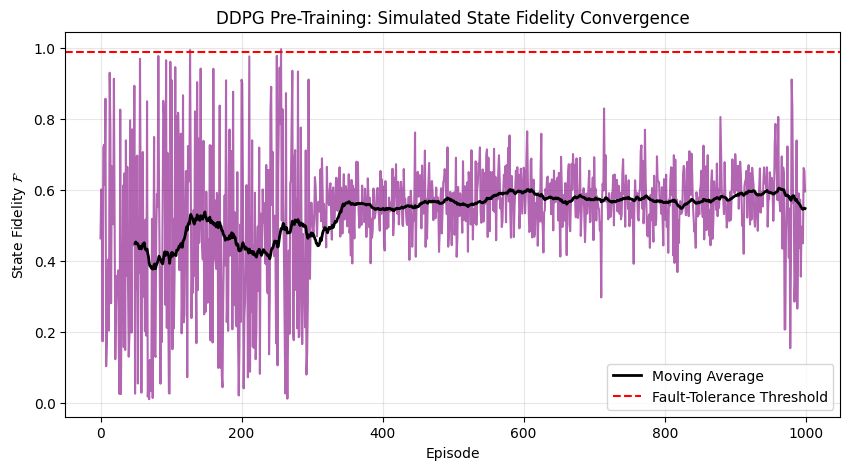

In [18]:
# [Colab Markdown: ## 5. Results Visualization]
plt.figure(figsize=(10, 5))
plt.plot(fidelities, color='purple', alpha=0.6)
# Smoothing the curve
window = 50
smoothed = np.convolve(fidelities, np.ones(window)/window, mode='valid')
plt.plot(np.arange(window-1, len(fidelities)), smoothed, color='black', linewidth=2, label='Moving Average')
plt.title('DDPG Pre-Training: Simulated State Fidelity Convergence')
plt.xlabel('Episode')
plt.ylabel('State Fidelity $\mathcal{F}$')
plt.axhline(y=0.99, color='r', linestyle='--', label='Fault-Tolerance Threshold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()